This example trains a [GRU-ODE](https://arxiv.org/abs/1905.12374) (a continuous time GRU-cells network) to predict a global parameter in a synthetic spirals dataset.

In [32]:
import time
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx # https://github.com/patrick-kidger/equinox
import diffrax
import optax # https://github.com/deepmind/optax
import matplotlib.pyplot as plt

We use [Equinox](https://github.com/patrick-kidger/equinox) to build neural networks and [Optax](https://github.com/deepmind/optax) for optimizers.

A **GRU-ODE** combines continuous-time latent dynamics with discrete observation updates. The hidden state evolves smoothly between observations and is updated instantaneously when new data becomes available.

### Continuous Evolution

Between observation times, the hidden state follows a neural ordinary differential equation:

$$
\frac{dh(t)}{dt} = f_{\theta}\!\left(h(t)\right)
$$

This term models how the latent state changes purely as a function of time.

### Discrete Updates

At each observation time $t_{i+1}$, the hidden state is updated using a GRU-style update rule that incorporates the new measurement. This update represents an instantaneous jump in the latent state.

### Continuous Dynamics Formulation

In a GRU-ODE, the continuous dynamics are defined to mirror the structure of a GRU update:

$$
f_{\theta}(h) = (1 - z) \odot (g - h)
$$

where:

- $z = \sigma(W_z h + b_z)$ is the update gate controlling the rate of change  
- $r = \sigma(W_r h + b_r)$ is the reset gate  
- $g = \tanh(W_g (r \odot h) + b_g)$ is the candidate state  

This can be interpreted as a continuous-time relaxation toward the candidate state rather than a discrete jump.

The function $f_{\theta}$ defined below is used by the ODE solver to evolve the hidden state between observations.


In [33]:
class ContinuousDynamics(eqx.Module):
    lin_z: eqx.nn.Linear
    lin_r: eqx.nn.Linear
    lin_g: eqx.nn.Linear

    def __init__(self, hidden_size, *, key):
        k1, k2, k3 = jr.split(key, 3)
        self.lin_z = eqx.nn.Linear(hidden_size, hidden_size, key=k1)
        self.lin_r = eqx.nn.Linear(hidden_size, hidden_size, key=k2)
        self.lin_g = eqx.nn.Linear(hidden_size, hidden_size, key=k3)

    def __call__(self, t, h, args):
        z = jax.nn.sigmoid(self.lin_z(h))
        r = jax.nn.sigmoid(self.lin_r(h))
        g = jax.nn.tanh(self.lin_g(r * h))
        return (1 - z) * (g - h)

Here we define the model that we use to recreate the ODE solve function.

In [34]:
class NeuralGRU(eqx.Module):
    continuous_dynamics: ContinuousDynamics
    discrete_update: eqx.nn.GRUCell
    linear: eqx.nn.Linear
    hidden_size: int

    def __init__(self, in_size, hidden_size, out_size, *, key):
        k1, k2, k3 = jr.split(key, 3)
        self.hidden_size = hidden_size
        self.continuous_dynamics = ContinuousDynamics(hidden_size, key=k1)
        self.discrete_update = eqx.nn.GRUCell(in_size, hidden_size, key=k2)
        self.linear = eqx.nn.Linear(hidden_size, out_size, key=k3)

    def __call__(self, ts, obs):
        h0 = jnp.zeros(self.hidden_size)
        init_carry = (h0, ts[0])
        xs = (ts[1:], obs[1:])

        def scan_fn(carry, x):
            h_prev, t_prev = carry
            t_curr, obs_curr = x
            
            sol = diffrax.diffeqsolve(
                diffrax.ODETerm(self.continuous_dynamics),
                diffrax.Tsit5(),
                t0=t_prev,
                t1=t_curr,
                dt0=t_curr - t_prev,
                y0=h_prev
            )
            h_prior = sol.ys[0]
            h_post = self.discrete_update(obs_curr, h_prior)
            return (h_post, t_curr), h_prior

        _, h_priors = jax.lax.scan(scan_fn, init_carry, xs)

        return jax.vmap(self.linear)(h_priors)

Toy dataset of nonlinear oscillators. Sample paths look like deformed sines and cosines.

In [35]:
def _get_data(ts, *, key):
    y0 = jr.uniform(key, (2,), minval=-0.6, maxval=1)

    def f(t, y, args):
        x = y / (1 + y)
        return jnp.stack([x[1], -x[0]], axis=-1)

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    return sol.ys

def get_data(dataset_size, *, key):
    ts = jnp.linspace(0, 10, 100)
    keys = jr.split(key, dataset_size)
    ys = jax.vmap(lambda k: _get_data(ts, key=k))(keys)
    
    split = int(dataset_size * 0.8)
    return ts, ys[:split], ys[split:]

In [36]:
def dataloader(data, batch_size, *, key):
    dataset_size = data.shape[0]
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            yield data[perm[start:end]]
            start = end
            end = start + batch_size

Main entry point. Try running `main()`.

Step: 0, Loss: 0.21765, Computation time: 1.837s
Step: 100, Loss: 0.00386, Computation time: 0.100s
Step: 200, Loss: 0.00325, Computation time: 0.119s
Step: 300, Loss: 0.00363, Computation time: 0.101s
Step: 400, Loss: 0.00299, Computation time: 0.100s
Step: 499, Loss: 0.00261, Computation time: 0.085s


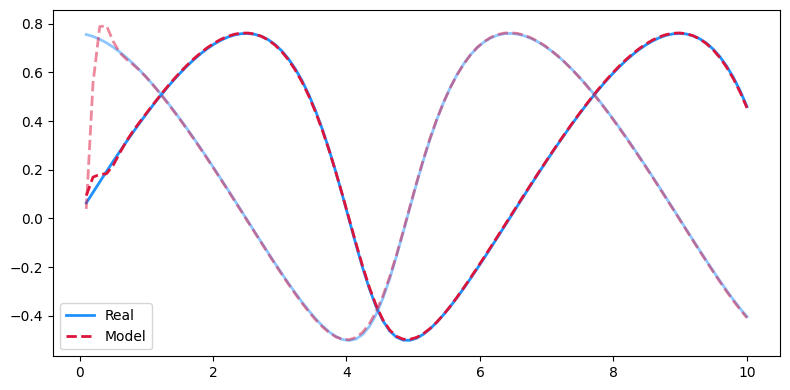

In [37]:
def main(
    dataset_size=256,
    batch_size=32,
    hidden_size=64,
    lr=3e-3,
    steps=500,
    seed=5678,
    print_every=100,
    plot=True
):
    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    ts, train_ys, test_ys = get_data(dataset_size, key=data_key)
    
    model = NeuralGRU(in_size=2, hidden_size=hidden_size, out_size=2, key=model_key)
    optim = optax.adamw(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_value_and_grad
    def grad_loss(model, batch_ts, batch_ys):
        preds = jax.vmap(model, in_axes=(None, 0))(batch_ts, batch_ys)
        targets = batch_ys[:, 1:, :]
        return jnp.mean((preds - targets) ** 2)

    @eqx.filter_jit
    def make_step(model, opt_state, batch_ts, batch_ys):
        loss, grads = grad_loss(model, batch_ts, batch_ys)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    # Training Loop
    for step, batch_ys in zip(range(steps), dataloader(train_ys, batch_size, key=loader_key)):
        start = time.time()
        loss, model, opt_state = make_step(model, opt_state, ts, batch_ys)
        end = time.time()

        if (step % print_every) == 0 or step == steps - 1:
            print(f"Step: {step}, Loss: {loss.item():.5f}, Computation time: {end - start:.3f}s")

    # Plotting
    if plot:
        sample_y = test_ys[0]
        pred_y = model(ts, sample_y)
        real_y = sample_y[1:]
        plot_ts = ts[1:]

        plt.figure(figsize=(8, 4))
        plt.plot(plot_ts, real_y[:, 0], c="dodgerblue", label="Real", lw=2)
        plt.plot(plot_ts, pred_y[:, 0], c="crimson", label="Model", ls="--", lw=2)
        plt.plot(plot_ts, real_y[:, 1], c="dodgerblue", lw=2, alpha=0.5)
        plt.plot(plot_ts, pred_y[:, 1], c="crimson", ls="--", lw=2, alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ts, model

if __name__ == "__main__":
    main()